# Baseline Benchmarks: FIGS, XGBoost, EBM on SC-OTS Datasets

This notebook benchmarks interpretable ML models — **FIGS** (Fast Interpretable Greedy-tree Sums), **XGBoost** (unconstrained + oracle-constrained), and **EBM** (Explainable Boosting Machines) — on the Friedman1 regression dataset using 5-fold cross-validation.

**What it measures:**
- Prediction performance (R², RMSE)
- Model complexity (number of splits/trees/terms)
- Training time

**Methods compared:**
1. **FIGS** (5/10/20 max rules) — sparse interpretable trees
2. **XGBoost-default** — unconstrained gradient boosting
3. **XGBoost-oracle** — constrained with known feature interactions
4. **EBM-default** — Explainable Boosting Machine with auto pairwise
5. **EBM-high-interaction** — EBM with more interaction terms

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# imodels, interpret — NOT on Colab, always install
_pip('imodels==1.4.4')
_pip('interpret==0.6.10')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1',
         'matplotlib==3.10.0', 'xgboost==3.1.3')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imodels 1.4.4 requires pandas<=2.1.4, but you have pandas 2.2.2 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import time
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from imodels import FIGSClassifier, FIGSRegressor
from xgboost import XGBClassifier, XGBRegressor
from interpret.glassbox import ExplainableBoostingClassifier, ExplainableBoostingRegressor

# Suppress noisy warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## Data Loading

Load the demo dataset (Friedman1 regression, 80 examples, 5-fold CV splits) from GitHub with local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-f5f9f2-simplicial-constrained-oblique-tree-sums/main/experiment_iter2_baseline_benchm/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {data['metadata']['n_datasets']} dataset(s), {data['metadata']['total_examples']} examples")

Loaded 1 dataset(s), 80 examples


## Configuration

All tunable parameters for the benchmark. Values are set for a quick demo run.

In [5]:
# === Tunable parameters ===
RANDOM_SEED = 42

# FIGS complexity levels (max rules per model)
FIGS_MAX_RULES = [5, 10, 20]

# XGBoost number of boosting rounds
XGB_N_ESTIMATORS = 100

# EBM parameters
EBM_OUTER_BAGS = 1
EBM_INNER_BAGS = 0
EBM_MAX_ROUNDS = 200
EBM_MAX_BINS = 128
EBM_INTERACTIONS = 30  # for high-interaction variant

# Number of CV folds to use (None = all available)
N_FOLDS = None  # Use all 5 folds

# Oracle constraints for friedman1
ORACLE_CONSTRAINTS = {
    "friedman1": {
        "groups_idx": [[0, 1], [2], [3], [4]],
        "description": "x0*x1 interact; x2,x3,x4 additive; rest noise",
    },
}

## Data Parsing

Parse the JSON dataset into numpy arrays with fold assignments, feature names, and task metadata.

In [6]:
def load_datasets(data: dict) -> dict:
    """Parse JSON data into dict keyed by dataset name with X, y, folds, etc."""
    ds_list = data.get("datasets", data)
    if isinstance(ds_list, dict):
        ds_list = [ds_list]

    result = {}
    for ds_entry in ds_list:
        ds_name = ds_entry["dataset"]
        examples = ds_entry["examples"]
        if not examples:
            continue

        first = examples[0]
        task_type = first["metadata_task_type"]
        feature_names = first.get("metadata_feature_names", [])
        known_raw = first.get("metadata_known_interactions")

        # Parse known interactions
        known_interactions = None
        if known_raw:
            if isinstance(known_raw, str):
                try:
                    known_interactions = json.loads(known_raw)
                except json.JSONDecodeError:
                    pass
            elif isinstance(known_raw, dict):
                known_interactions = known_raw

        rows, targets, folds = [], [], []
        for ex in examples:
            features = json.loads(ex["input"]) if isinstance(ex["input"], str) else ex["input"]
            rows.append(features)
            folds.append(ex["metadata_fold"])
            targets.append(ex["output"])

        X = np.array(rows, dtype=np.float64)
        fold_arr = np.array(folds, dtype=int)

        if task_type == "classification":
            le = LabelEncoder()
            y = le.fit_transform([str(t) for t in targets]).astype(np.int64)
        else:
            y = np.array([float(t) for t in targets], dtype=np.float64)

        result[ds_name] = {
            "X": X, "y": y, "folds": fold_arr,
            "task_type": task_type,
            "feature_names": feature_names if feature_names else [f"f{i}" for i in range(X.shape[1])],
            "known_interactions": known_interactions,
            "n_samples": X.shape[0], "n_features": X.shape[1],
        }

    for name, ds in result.items():
        print(f"  {name}: {ds['n_samples']} samples, {ds['n_features']} features, "
              f"task={ds['task_type']}, folds={sorted(np.unique(ds['folds']))}")
    return result

datasets = load_datasets(data)

  friedman1: 80 samples, 10 features, task=regression, folds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## Helper Functions

Metrics computation, complexity extraction, fold splitting, and timed model fitting.

In [7]:
def get_fold_splits(X, y, folds, fold_idx):
    """Return (X_train, y_train, X_test, y_test) for a given fold."""
    train_mask = folds != fold_idx
    test_mask = folds == fold_idx
    return X[train_mask], y[train_mask], X[test_mask], y[test_mask]


def compute_metrics(model, X_test, y_test, task_type):
    """Compute performance metrics for a fitted model on test data."""
    metrics = {}
    preds = model.predict(X_test)

    if task_type == "classification":
        metrics["accuracy"] = float(round(accuracy_score(y_test, preds), 6))
        try:
            n_classes = len(np.unique(y_test))
            if n_classes == 2:
                proba = model.predict_proba(X_test)
                metrics["auroc"] = float(round(roc_auc_score(y_test, proba[:, 1]), 6))
            elif n_classes > 2:
                proba = model.predict_proba(X_test)
                metrics["auroc"] = float(round(
                    roc_auc_score(y_test, proba, multi_class="ovr", average="weighted"), 6))
            else:
                metrics["auroc"] = float("nan")
        except Exception:
            metrics["auroc"] = float("nan")
    else:
        metrics["r2"] = float(round(r2_score(y_test, preds), 6))
        metrics["rmse"] = float(round(np.sqrt(mean_squared_error(y_test, preds)), 6))
    return metrics


def extract_complexity(model, method_name):
    """Extract complexity metrics from a fitted model."""
    complexity = {}
    if method_name.startswith("FIGS"):
        complexity["n_splits"] = int(getattr(model, "complexity_", 0))
        complexity["n_trees"] = len(getattr(model, "trees_", []))
    elif method_name.startswith("XGBoost"):
        try:
            booster = model.get_booster()
            dump = booster.get_dump()
            complexity["n_trees"] = len(dump)
            complexity["n_splits"] = sum(
                1 for tree_str in dump for line in tree_str.strip().split("\n") if "[" in line)
        except Exception:
            complexity["n_splits"] = -1
            complexity["n_trees"] = -1
    elif method_name.startswith("EBM"):
        terms = getattr(model, "term_features_", [])
        complexity["n_total_terms"] = len(terms)
        complexity["n_main_effects"] = sum(1 for t in terms if len(t) == 1)
        complexity["n_pairwise"] = sum(1 for t in terms if len(t) == 2)
    return complexity


def compute_fold_summary(fold_metrics, fold_complexities, fold_times):
    """Aggregate per-fold results into mean+/-std summary."""
    summary = {}
    if not fold_metrics:
        return summary
    for key in fold_metrics[0]:
        vals = [fm[key] for fm in fold_metrics
                if not (isinstance(fm[key], float) and np.isnan(fm[key]))]
        if vals:
            summary[f"{key}_mean"] = round(float(np.mean(vals)), 6)
            summary[f"{key}_std"] = round(float(np.std(vals)), 6)
    if fold_complexities:
        summary["complexity"] = fold_complexities[0]
    summary["train_time_mean"] = round(float(np.mean(fold_times)), 4)
    summary["train_time_std"] = round(float(np.std(fold_times)), 4)
    return summary

## Model Configuration

Build model factories for all methods: FIGS (variable complexity), XGBoost (default + oracle), and EBM (default + high-interaction).

In [8]:
def _get_oracle_constraints_for_xgb(dataset_name, dataset_meta, feature_names):
    """Build interaction_constraints for XGBoost oracle, using feature name strings."""
    cfg = ORACLE_CONSTRAINTS.get(dataset_name)
    if cfg is None:
        return None
    n_features = len(feature_names)
    if isinstance(cfg, dict) and "groups_idx" in cfg:
        idx_groups = cfg["groups_idx"]
        covered = set()
        for g in idx_groups:
            covered.update(g)
        all_groups = list(idx_groups)
        for i in range(n_features):
            if i not in covered:
                all_groups.append([i])
        return [[feature_names[i] for i in g] for g in all_groups]
    return None


def build_model_configs(datasets):
    """Build all model configurations for benchmarking."""
    configs = []

    # 1. FIGS variants
    for max_rules in FIGS_MAX_RULES:
        def _figs_factory(task_type, dataset_name, dataset_meta, _mr=max_rules):
            if task_type == "classification":
                return FIGSClassifier(max_rules=_mr, random_state=RANDOM_SEED)
            return FIGSRegressor(max_rules=_mr, random_state=RANDOM_SEED)
        configs.append({"name": f"FIGS-{max_rules}", "factory": _figs_factory,
                        "is_applicable": lambda ds_name, ds: True})

    # 2. XGBoost default
    def _xgb_default_factory(task_type, dataset_name, dataset_meta):
        if task_type == "classification":
            return XGBClassifier(n_estimators=XGB_N_ESTIMATORS, random_state=RANDOM_SEED,
                                 eval_metric="logloss", n_jobs=1, verbosity=0)
        return XGBRegressor(n_estimators=XGB_N_ESTIMATORS, random_state=RANDOM_SEED,
                            n_jobs=1, verbosity=0)
    configs.append({"name": "XGBoost-default", "factory": _xgb_default_factory,
                    "is_applicable": lambda ds_name, ds: True})

    # 3. XGBoost oracle (only for datasets with known constraints)
    def _xgb_oracle_factory(task_type, dataset_name, dataset_meta):
        feature_names = dataset_meta["feature_names"]
        constraints = _get_oracle_constraints_for_xgb(dataset_name, dataset_meta, feature_names)
        if constraints is None:
            raise ValueError(f"No oracle constraints for {dataset_name}")
        if task_type == "classification":
            return XGBClassifier(n_estimators=XGB_N_ESTIMATORS, random_state=RANDOM_SEED,
                                 eval_metric="logloss", interaction_constraints=constraints,
                                 n_jobs=1, verbosity=0)
        return XGBRegressor(n_estimators=XGB_N_ESTIMATORS, random_state=RANDOM_SEED,
                            interaction_constraints=constraints, n_jobs=1, verbosity=0)
    configs.append({"name": "XGBoost-oracle", "factory": _xgb_oracle_factory,
                    "is_applicable": lambda ds_name, ds: ds_name in ORACLE_CONSTRAINTS})

    # 4. EBM default
    def _ebm_default_factory(task_type, dataset_name, dataset_meta):
        if task_type == "classification":
            return ExplainableBoostingClassifier(random_state=RANDOM_SEED, n_jobs=1,
                outer_bags=EBM_OUTER_BAGS, inner_bags=EBM_INNER_BAGS,
                max_rounds=EBM_MAX_ROUNDS, max_bins=EBM_MAX_BINS)
        return ExplainableBoostingRegressor(random_state=RANDOM_SEED, n_jobs=1,
            outer_bags=EBM_OUTER_BAGS, inner_bags=EBM_INNER_BAGS,
            max_rounds=EBM_MAX_ROUNDS, max_bins=EBM_MAX_BINS)
    configs.append({"name": "EBM-default", "factory": _ebm_default_factory,
                    "is_applicable": lambda ds_name, ds: True})

    # 5. EBM high-interaction
    def _ebm_high_factory(task_type, dataset_name, dataset_meta):
        if task_type == "classification":
            return ExplainableBoostingClassifier(interactions=EBM_INTERACTIONS, max_bins=EBM_MAX_BINS,
                max_interaction_bins=32, random_state=RANDOM_SEED, n_jobs=1,
                outer_bags=EBM_OUTER_BAGS, inner_bags=EBM_INNER_BAGS, max_rounds=EBM_MAX_ROUNDS)
        return ExplainableBoostingRegressor(interactions=EBM_INTERACTIONS, max_bins=EBM_MAX_BINS,
            max_interaction_bins=32, random_state=RANDOM_SEED, n_jobs=1,
            outer_bags=EBM_OUTER_BAGS, inner_bags=EBM_INNER_BAGS, max_rounds=EBM_MAX_ROUNDS)
    configs.append({"name": "EBM-high-interaction", "factory": _ebm_high_factory,
                    "is_applicable": lambda ds_name, ds: True})

    return configs

model_configs = build_model_configs(datasets)
print(f"Built {len(model_configs)} model configs: {[m['name'] for m in model_configs]}")

Built 7 model configs: ['FIGS-5', 'FIGS-10', 'FIGS-20', 'XGBoost-default', 'XGBoost-oracle', 'EBM-default', 'EBM-high-interaction']


## Run Benchmark

Train each model on each fold, compute metrics and complexity, then aggregate results.

In [9]:
all_results = {}
total_start = time.time()

for ds_name, ds in datasets.items():
    print(f"=== Dataset: {ds_name} ({ds['task_type']}, {ds['n_samples']} samples) ===")
    all_results[ds_name] = {}
    feature_names = ds["feature_names"]
    unique_folds = sorted(np.unique(ds["folds"]))

    # Limit number of folds if configured
    if N_FOLDS is not None:
        unique_folds = unique_folds[:N_FOLDS]
        print(f"  Using {len(unique_folds)} fold(s): {unique_folds}")

    for mcfg in model_configs:
        method_name = mcfg["name"]
        if not mcfg["is_applicable"](ds_name, ds):
            print(f"  Skipping {method_name} (not applicable)")
            continue

        print(f"  Running {method_name}...", end="")
        all_results[ds_name][method_name] = {}
        fold_metrics_list, fold_complexities_list, fold_times_list = [], [], []

        for fold_idx in unique_folds:
            X_train, y_train, X_test, y_test = get_fold_splits(
                ds["X"], ds["y"], ds["folds"], fold_idx)

            if len(y_train) < 2 or len(y_test) < 1:
                continue

            try:
                model = mcfg["factory"](task_type=ds["task_type"],
                                         dataset_name=ds_name, dataset_meta=ds)
            except Exception as e:
                all_results[ds_name][method_name][str(fold_idx)] = {"error": str(e)}
                continue

            # Use DataFrame for XGBoost (needed for interaction_constraints)
            if method_name.startswith("XGBoost"):
                X_train_fit = pd.DataFrame(X_train, columns=feature_names)
                X_test_fit = pd.DataFrame(X_test, columns=feature_names)
            else:
                X_train_fit, X_test_fit = X_train, X_test

            try:
                start = time.perf_counter()
                model.fit(X_train_fit, y_train)
                elapsed = time.perf_counter() - start
            except Exception as e:
                all_results[ds_name][method_name][str(fold_idx)] = {"error": str(e)}
                continue

            metrics = compute_metrics(model, X_test_fit, y_test, ds["task_type"])
            complexity = extract_complexity(model, method_name)

            fold_result = {
                "metrics": metrics, "complexity": complexity,
                "train_time_sec": round(elapsed, 4),
                "n_train": int(len(y_train)), "n_test": int(len(y_test)),
            }
            all_results[ds_name][method_name][str(fold_idx)] = fold_result
            fold_metrics_list.append(metrics)
            fold_complexities_list.append(complexity)
            fold_times_list.append(elapsed)

        if fold_metrics_list:
            summary = compute_fold_summary(fold_metrics_list, fold_complexities_list, fold_times_list)
            all_results[ds_name][method_name]["summary"] = summary
            primary = (f"R²={summary.get('r2_mean', 'N/A')}" if "r2_mean" in summary
                       else f"acc={summary.get('accuracy_mean', 'N/A')}")
            print(f" {primary}, time={summary['train_time_mean']:.3f}s")
        else:
            print(" (no successful folds)")

total_time = time.time() - total_start
print(f"\nTotal benchmark time: {total_time:.1f}s")

=== Dataset: friedman1 (regression, 80 samples) ===
  Running FIGS-5...

 R²=0.535456, time=0.025s
  Running FIGS-10...

 R²=0.58646, time=0.071s
  Running FIGS-20...

 R²=0.524483, time=0.184s
  Running XGBoost-default...

 R²=0.58366, time=0.061s
  Running XGBoost-oracle...

 R²=0.539779, time=0.049s
  Running EBM-default...

 R²=0.861805, time=1.007s
  Running EBM-high-interaction...

 R²=0.873135, time=1.100s

Total benchmark time: 13.2s


## Results Summary & Visualization

Display results as a summary table and bar chart comparing methods by R² and training time.

=== Benchmark Results ===
  Dataset               Method  R² (mean)  R² (std)  RMSE (mean)  Train Time (s)             Complexity
friedman1               FIGS-5   0.535456  0.136848     2.980603          0.0251      5 splits, 3 trees
friedman1              FIGS-10   0.586460  0.089738     2.837165          0.0714     10 splits, 4 trees
friedman1              FIGS-20   0.524483  0.206456     2.972715          0.1840     20 splits, 4 trees
friedman1      XGBoost-default   0.583660  0.208361     2.771771          0.0614  864 splits, 100 trees
friedman1       XGBoost-oracle   0.539779  0.146969     3.008354          0.0486 1403 splits, 100 trees
friedman1          EBM-default   0.861805  0.039245     1.626163          1.0066      19 terms (10+9pw)
friedman1 EBM-high-interaction   0.873135  0.031974     1.562618          1.0996     40 terms (10+30pw)


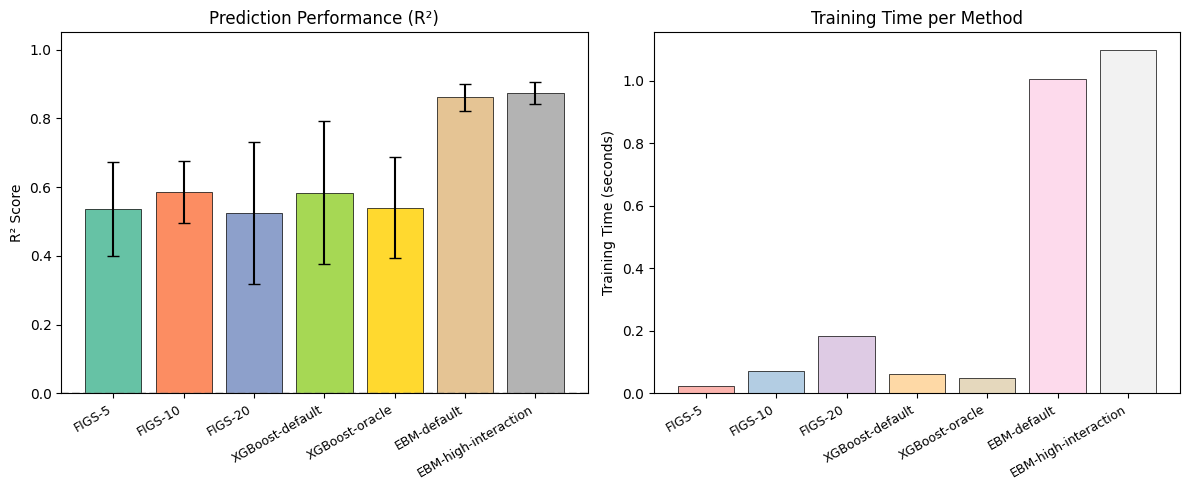

Plot saved to benchmark_results.png


In [10]:
# === Summary Table ===
rows = []
for ds_name, ds_results in all_results.items():
    for method_name, method_results in ds_results.items():
        summary = method_results.get("summary", {})
        if not summary:
            continue
        row = {"Dataset": ds_name, "Method": method_name}
        if "r2_mean" in summary:
            row["R² (mean)"] = summary["r2_mean"]
            row["R² (std)"] = summary["r2_std"]
            row["RMSE (mean)"] = summary.get("rmse_mean", float("nan"))
        elif "accuracy_mean" in summary:
            row["Accuracy (mean)"] = summary["accuracy_mean"]
            row["Accuracy (std)"] = summary["accuracy_std"]
        row["Train Time (s)"] = summary.get("train_time_mean", float("nan"))
        # Complexity info
        comp = summary.get("complexity", {})
        if "n_splits" in comp:
            row["Complexity"] = f"{comp['n_splits']} splits, {comp['n_trees']} trees"
        elif "n_total_terms" in comp:
            row["Complexity"] = f"{comp['n_total_terms']} terms ({comp['n_main_effects']}+{comp['n_pairwise']}pw)"
        rows.append(row)

df_summary = pd.DataFrame(rows)
print("=== Benchmark Results ===")
print(df_summary.to_string(index=False))

# === Visualization ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods = df_summary["Method"].tolist()
x = np.arange(len(methods))

# R² bar chart
if "R² (mean)" in df_summary.columns:
    r2_vals = df_summary["R² (mean)"].tolist()
    r2_stds = df_summary["R² (std)"].tolist()
    colors = plt.cm.Set2(np.linspace(0, 1, len(methods)))
    axes[0].bar(x, r2_vals, yerr=r2_stds, color=colors, capsize=4, edgecolor="black", linewidth=0.5)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(methods, rotation=30, ha="right", fontsize=9)
    axes[0].set_ylabel("R² Score")
    axes[0].set_title("Prediction Performance (R²)")
    axes[0].set_ylim(0, 1.05)
    axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.3)

# Training time bar chart
train_times = df_summary["Train Time (s)"].tolist()
axes[1].bar(x, train_times, color=plt.cm.Pastel1(np.linspace(0, 1, len(methods))),
            edgecolor="black", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=30, ha="right", fontsize=9)
axes[1].set_ylabel("Training Time (seconds)")
axes[1].set_title("Training Time per Method")

plt.tight_layout()
plt.savefig("benchmark_results.png", dpi=100, bbox_inches="tight")
plt.show()
print("Plot saved to benchmark_results.png")